Here we will test the algorithm of Douglas-Peucker without pymeos (MovingPandas library), and with pymeos (MobilityPandas library). We use a version of this algorithm using the distances at a certain time, instead of the shortest distance between segments, in order to take the time into account.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

from geopandas import GeoDataFrame, read_file
import zipfile

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
from pyproj import Transformer

import pymeos
from pymeos.mixins.simplify import TSimplifiable
from pymeos import TGeomPointSeq
pymeos.pymeos_initialize()

We use AIS data.

In [2]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'large': 5000000}
chosen_size = 'small'

## MovingPandas (without PyMEOS)

In [3]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )

    global nb_points
    nb_points = df.shape[0]

# extraction()

In [4]:
def construction_without():
    df1 = df.copy()
    df1['geometry'] = [Point(lon, lat) for lon, lat in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])
    gdf = gdf.drop(columns=['lat', 'lon'])

    global trajectories_without
    trajectories_without = mpd.TrajectoryCollection(gdf, traj_id_col='mmsi', t='t')

# construction_without()

## MobilityPandas (with PyMEOS)
We use `from_arrays` method.

In [5]:
def construction_with():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

# construction_with()

## Simplification

In [6]:
def simplify_with():
    global simplified_with
    simplified_with = trajectories_with.trajectory.apply(
        lambda x: TSimplifiable.simplify_douglas_peucker(x, distance=1, synchronized=True)
    )

# simplify_with()

In [7]:
def simplify_without():
    global simplified_without
    simplified_without = mpd.TopDownTimeRatioGeneralizer(trajectories_without).generalize(tolerance=1)
    
# simplify_without()

## Measures

In [8]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=4):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)
    # results[f.__name__] = (mean_t, 0)  # if you don't want to calculate memory usage


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_without)
benchmark_cpu_time(construction_with)
benchmark_cpu_time(simplify_without)
benchmark_cpu_time(simplify_with)

Function extraction:
CPU time over 4 runs: 3.361714 sec ± 0.022763 sec
Memory usage : 111.55 MiB

Function construction_without:
CPU time over 4 runs: 3.140617 sec ± 0.006338 sec
Memory usage : 4.88 MiB

Function construction_with:
CPU time over 4 runs: 0.913314 sec ± 0.025374 sec
Memory usage : 1.00 MiB

Function simplify_without:
CPU time over 4 runs: 21.447609 sec ± 0.059072 sec
Memory usage : 0.25 MiB

Function simplify_with:
CPU time over 4 runs: 0.031274 sec ± 0.000520 sec
Memory usage : 0.12 MiB



In [9]:
# extraction()
# construction_without()
# construction_with()
# simplify_without()
# simplify_with()

# Performance measures

## Reduction

In [10]:
kept_points_without = 0
for traj in simplified_without.trajectories :
    kept_points_without += traj.size()

kept_points_with = 0
for traj in simplified_with :
    kept_points_with += traj.num_instants()

print("Percentage of points kept : (without pymeos, with pymeos)")
print(np.round(kept_points_without*100/nb_points, 2), '%,  ',
      np.round(kept_points_with*100/nb_points, 2), '%,  ')

Percentage of points kept : (without pymeos, with pymeos)
49.13 %,   52.51 %,  


## Time and memory

### Construction of the trajectories

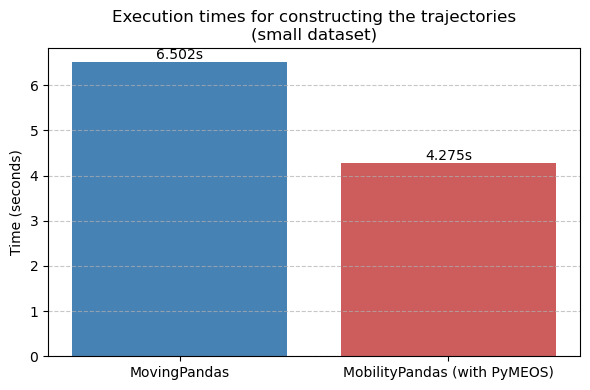

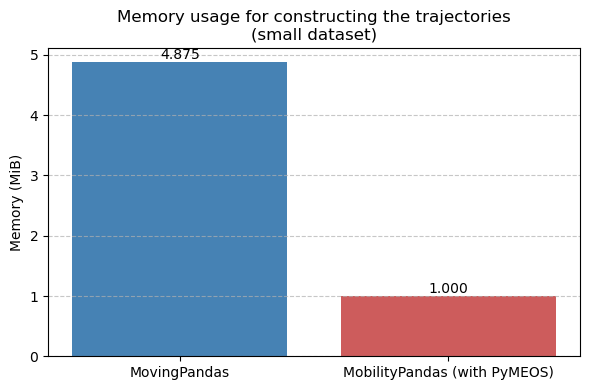

In [11]:
timesCo = [results['extraction'][0] + results['construction_without'][0], results['extraction'][0]+ results['construction_with'][0]]
memCo = [results['construction_without'][1], results['construction_with'][1]]
libs = ['MovingPandas', 'MobilityPandas (with PyMEOS)']


plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Calculation

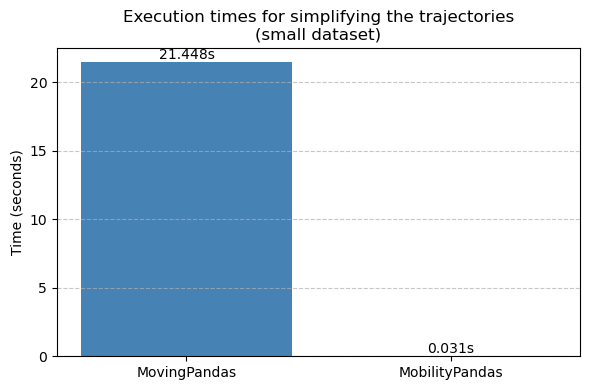

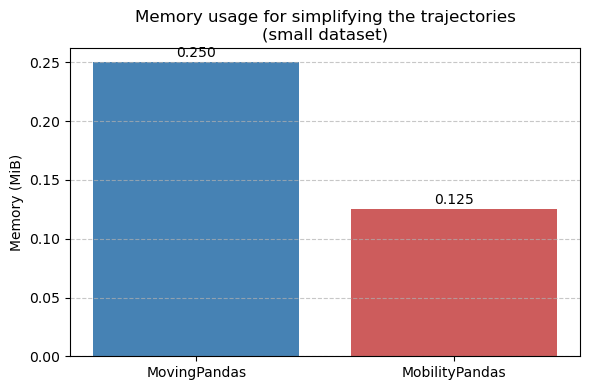

In [12]:
timesCa = [results['simplify_without'][0], results['simplify_with'][0]]
memCa = [results['simplify_without'][1], results['simplify_with'][1]]
libsCa = ['MovingPandas', 'MobilityPandas']

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, timesCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libsCa, memCa, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for simplifying the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Complete process

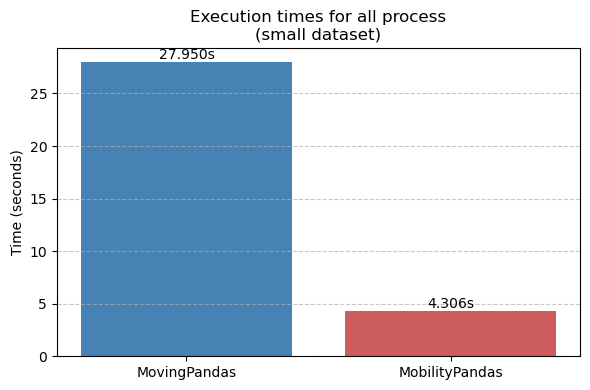

In [13]:
times = [results['extraction'][0] + results['construction_without'][0] + results['simplify_without'][0], 
         results['extraction'][0]+ results['construction_with'][0] + results['simplify_with'][0]]

libs = ['MovingPandas', 'MobilityPandas']

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for all process\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Preservation

### Spatial-temporal distortion
(area)

In [14]:
def calc_distortion_without():
    distortion_for_each_traj = []

    trajs_original = list(trajectories_without.trajectories)
    trajs_simplified = list(simplified_without.trajectories)

    for ti, ts in zip(trajs_original, trajs_simplified):
        timestamps = ti.df.index

        delta_t = np.diff(timestamps).astype('timedelta64[s]').astype(float)

        # extracting the positions at a same time for the two trajectories to compare 
        # left rectangles
        p1lefts, p2lefts = [ti.interpolate_position_at(timestamps[0])], [ts.get_position_at(timestamps[0])] # offset of one
        p1rights, p2rights = [], []

        for t in timestamps[1:-1]:

                p1lefts.append(ti.interpolate_position_at(t))
                p2lefts.append(ts.get_position_at(t))

                p1rights.append(ti.interpolate_position_at(t))
                p2rights.append(ts.get_position_at(t))

        p1rights.append(ti.interpolate_position_at(timestamps[-1]))
        p2rights.append(ts.get_position_at(timestamps[-1]))

        # distances between the two trajectories
        dlefts = np.array([p1.distance(p2) for p1, p2 in zip(p1lefts, p2lefts)])
        drights = np.array([p1.distance(p2) for p1, p2 in zip(p1rights, p2rights)])

        # time * trapeze area, ie integration (vectorized)
        total_area = 0.5 * (dlefts + drights) * delta_t  # [m * s]
        distortion_for_each_traj.append(total_area.sum() / 3600)  # [m * h]

    return distortion_for_each_traj


distortion_without = calc_distortion_without()

In [15]:
distortion_with = np.array([trajectories_with.trajectory.values[i].distance(simplified_with.values[i]).integral()
        for i in range(len(trajectories_with.trajectory.values))])/(3600*10**6)

# TODO : note that even this calculation is much faster with PyMEOS.

In [16]:
print("maximum distortion without pymeos: ", round(max(distortion_without), 2), 'h*m,  ')
print("average distortion without pymeos: ", round(np.mean(distortion_without), 2), 'h*m,  ')

print("maximum distortion with pymeos: ", round(max(distortion_with), 2), 'h*m,  ')
print("average distortion with pymeos: ", round(np.mean(distortion_with), 2), 'h*m,  ')

maximum distortion without pymeos:  0.04 h*m,  
average distortion without pymeos:  0.01 h*m,  
maximum distortion with pymeos:  0.04 h*m,  
average distortion with pymeos:  0.01 h*m,  


### Total length of the trajectories

In [17]:
list_of_mmsi = [traj.id for traj in trajectories_without]

diff_without, diff_with = [], []
for i in range(len(trajectories_without.trajectories)):
      m = list_of_mmsi[i]
      lo = round(trajectories_without.trajectories[i].get_length(), 2)
      lwithout = round(simplified_without.trajectories[i].get_length(), 2)
      lwith2 = round(simplified_with[m].length(), 2)

      diff_without.append(abs(lo-lwithout))
      diff_with.append(abs(lo-lwith2))

print(f"Maximum length difference without pymeos: {round(max(diff_without), 2)} m,   with pymeos: {round(max(diff_with), 2)} m")
print(f"Average length difference without pymeos: {round(np.mean(diff_without), 2)} m,   with pymeos: {round(np.mean(diff_with), 2)} m")

Maximum length difference without pymeos: 13.04 m,   with pymeos: 13.04 m
Average length difference without pymeos: 0.5 m,   with pymeos: 0.5 m


## Let see

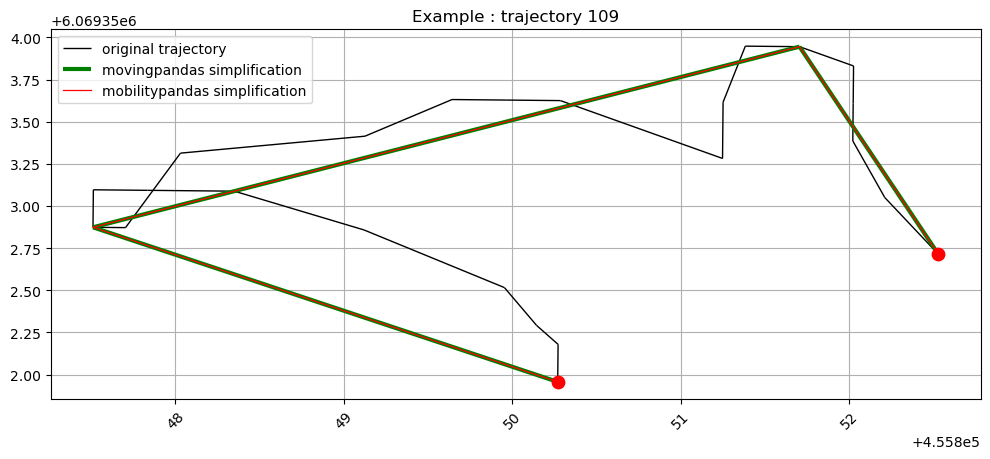

In [18]:
# Plot one trajectory

# n=109 is a good one
n=109
m = [traj.id for traj in trajectories_without][n] # the corresponding MMSI

fig, ax = plt.subplots(figsize=(12, 8))
trajectories_without.trajectories[n].plot(color='black', label='original trajectory', linewidth=1, ax=ax)
simplified_without.trajectories[n].plot(color='green', label='movingpandas simplification', ax=ax, linewidth=3)
simplified_with[m].plot(color='red', label='mobilitypandas simplification', linewidth=0.9)

plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()